In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
datos = pd.read_csv("datos\\Datos SINAICA.csv", encoding='latin1', engine='python')
datos.dropna(inplace=True)
datos.head()

,Parametro,Fecha,Hora,Concentraciones horarias,Unidad
0,PM10,01/08/2025,23:00 - 0:00,27,µg/m_
1,PM10,01/08/2025,0:00 - 1:00,34,µg/m_
2,PM10,01/08/2025,1:00 - 2:00,5,µg/m_
3,PM10,01/08/2025,2:00 - 3:00,-7,µg/m_
4,PM10,01/08/2025,3:00 - 4:00,20,µg/m_


Text(0.5, 1.0, 'Concentración datos crudos')

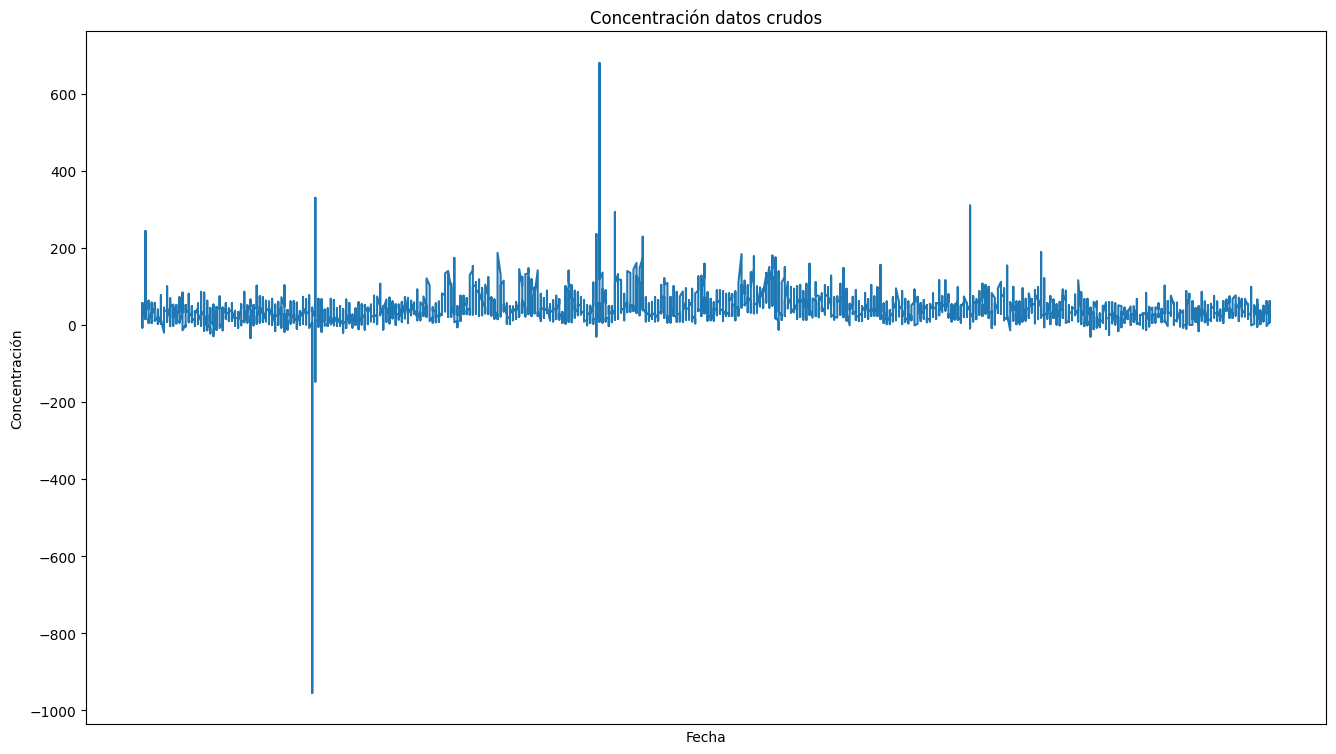

In [4]:
plt.figure(figsize=(16,9))
plt.plot(datos['Fecha'], datos['Concentraciones horarias'])
plt.ylabel('Concentración')
plt.xticks([])
plt.xlabel('Fecha')
plt.title('Concentración datos crudos')

## Smoothing by day

### mean

In [6]:
datos['Mean_by_day']=datos.groupby("Fecha")['Concentraciones horarias'].transform('mean')
datos.head()

,Parametro,Fecha,Hora,Concentraciones horarias,Unidad,Mean_by_day
0,PM10,01/08/2025,23:00 - 0:00,27,µg/m_,25.333333
1,PM10,01/08/2025,0:00 - 1:00,34,µg/m_,25.333333
2,PM10,01/08/2025,1:00 - 2:00,5,µg/m_,25.333333
3,PM10,01/08/2025,2:00 - 3:00,-7,µg/m_,25.333333
4,PM10,01/08/2025,3:00 - 4:00,20,µg/m_,25.333333


Text(0.5, 1.0, 'Smoothing por bin_mean por dia')

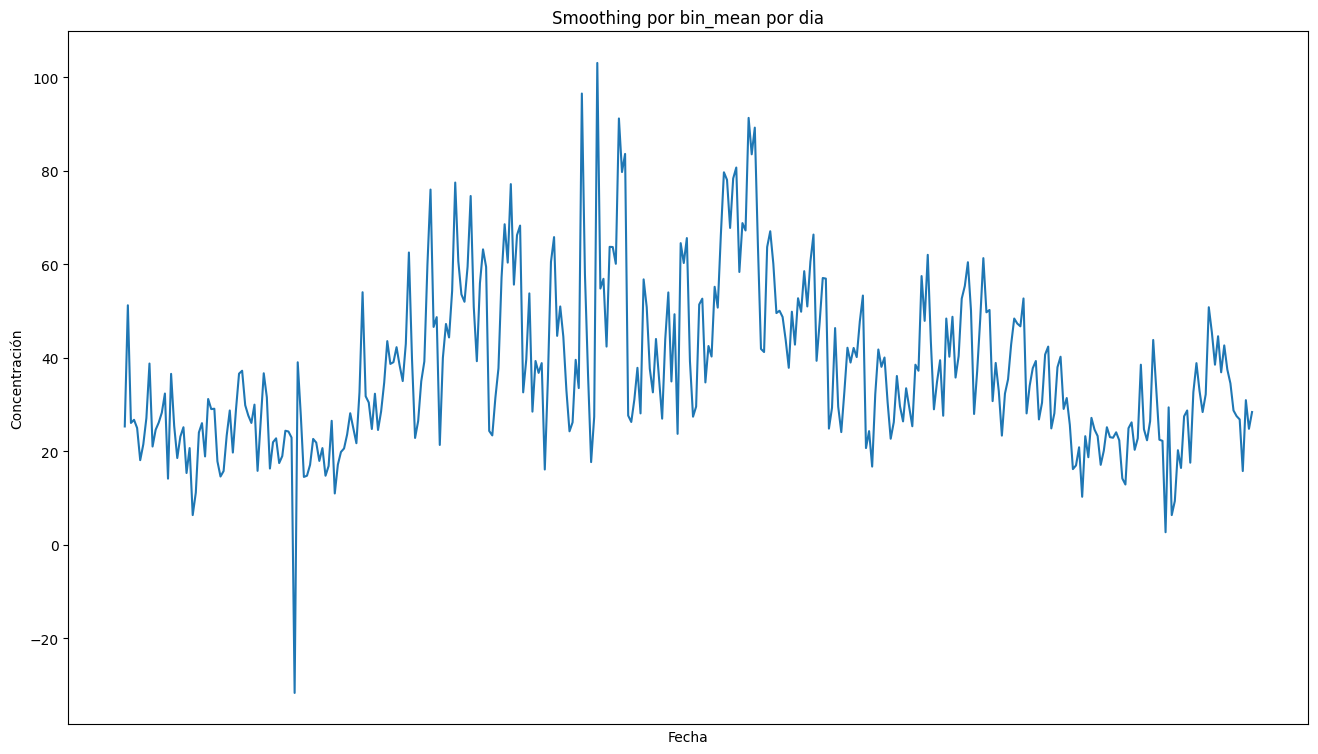

In [ ]:
plt.figure(figsize=(16,9))
plt.plot(datos['Fecha'], datos['Mean_by_day'])
plt.ylabel('Concentración')
plt.xticks([])
plt.xlabel('Fecha')
plt.title('Smoothing por la media por dia')

### median

In [10]:
datos['Median_by_day']=datos.groupby("Fecha")['Concentraciones horarias'].transform('median')
datos.head()

,Parametro,Fecha,Hora,Concentraciones horarias,Unidad,Mean_by_day,Median_by_day
0,PM10,01/08/2025,23:00 - 0:00,27,µg/m_,25.333333,24.0
1,PM10,01/08/2025,0:00 - 1:00,34,µg/m_,25.333333,24.0
2,PM10,01/08/2025,1:00 - 2:00,5,µg/m_,25.333333,24.0
3,PM10,01/08/2025,2:00 - 3:00,-7,µg/m_,25.333333,24.0
4,PM10,01/08/2025,3:00 - 4:00,20,µg/m_,25.333333,24.0


Text(0.5, 1.0, 'Smoothing por la mediana por dia')

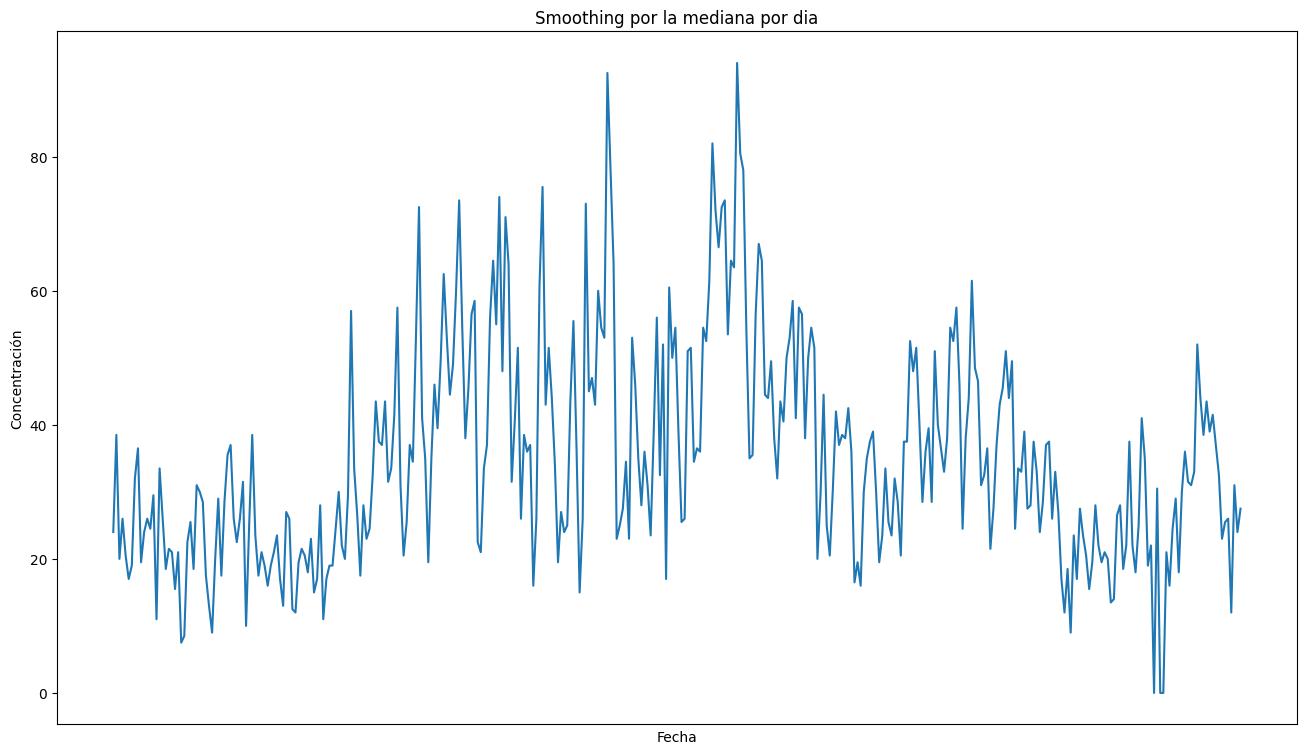

In [12]:
plt.figure(figsize=(16,9))
plt.plot(datos['Fecha'], datos['Median_by_day'])
plt.ylabel('Concentración')
plt.xticks([])
plt.xlabel('Fecha')
plt.title('Smoothing por la mediana por dia')

### boundaries

In [14]:
limite_min = datos.groupby('Fecha')['Concentraciones horarias'].transform('min')
limite_max = datos.groupby('Fecha')['Concentraciones horarias'].transform('max')

distancia_al_min = abs(datos['Concentraciones horarias'] - limite_min)
distancia_al_max = abs(limite_max - datos['Concentraciones horarias'])

datos['boundary_day'] = np.where(distancia_al_min < distancia_al_max, limite_min, limite_max)
datos.head()

,Parametro,Fecha,Hora,Concentraciones horarias,Unidad,Mean_by_day,Median_by_day,boundary_day
0,PM10,01/08/2025,23:00 - 0:00,27,µg/m_,25.333333,24.0,57
1,PM10,01/08/2025,0:00 - 1:00,34,µg/m_,25.333333,24.0,57
2,PM10,01/08/2025,1:00 - 2:00,5,µg/m_,25.333333,24.0,-7
3,PM10,01/08/2025,2:00 - 3:00,-7,µg/m_,25.333333,24.0,-7
4,PM10,01/08/2025,3:00 - 4:00,20,µg/m_,25.333333,24.0,-7


Text(0.5, 1.0, 'Smoothing por boundary por dia')

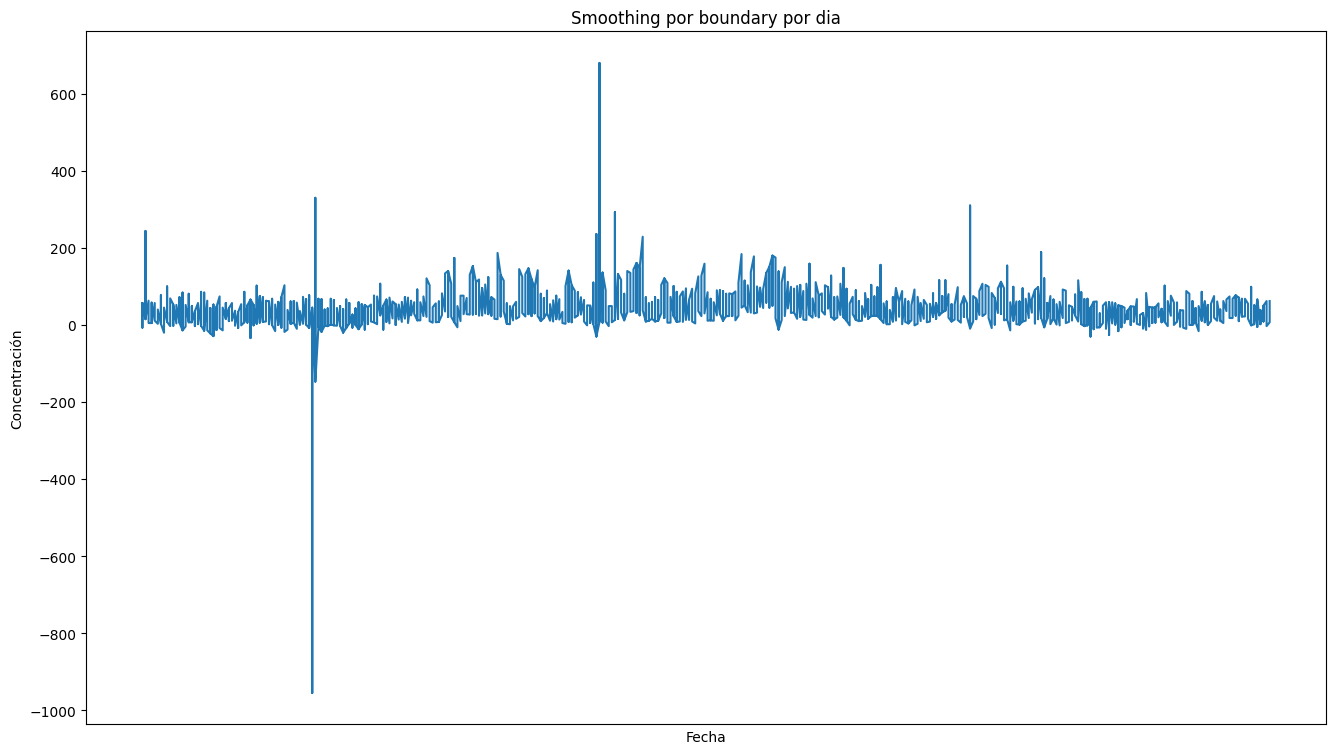

In [16]:
plt.figure(figsize=(16,9))
plt.plot(datos['Fecha'], datos['boundary_day'])
plt.ylabel('Concentración')
plt.xticks([])
plt.xlabel('Fecha')
plt.title('Smoothing por boundary por dia')

## Smoothing moving average

In [17]:
datos['Moving_average'] = datos['Concentraciones horarias'].rolling(window=5,center=True).mean()
datos.head()

,Parametro,Fecha,Hora,Concentraciones horarias,Unidad,Mean_by_day,Median_by_day,boundary_day,Moving_average
0,PM10,01/08/2025,23:00 - 0:00,27,µg/m_,25.333333,24.0,57,NaN
1,PM10,01/08/2025,0:00 - 1:00,34,µg/m_,25.333333,24.0,57,NaN
2,PM10,01/08/2025,1:00 - 2:00,5,µg/m_,25.333333,24.0,-7,15.8
3,PM10,01/08/2025,2:00 - 3:00,-7,µg/m_,25.333333,24.0,-7,14.2
4,PM10,01/08/2025,3:00 - 4:00,20,µg/m_,25.333333,24.0,-7,8.6


Text(0.5, 1.0, 'Smoothing por promedio movil')

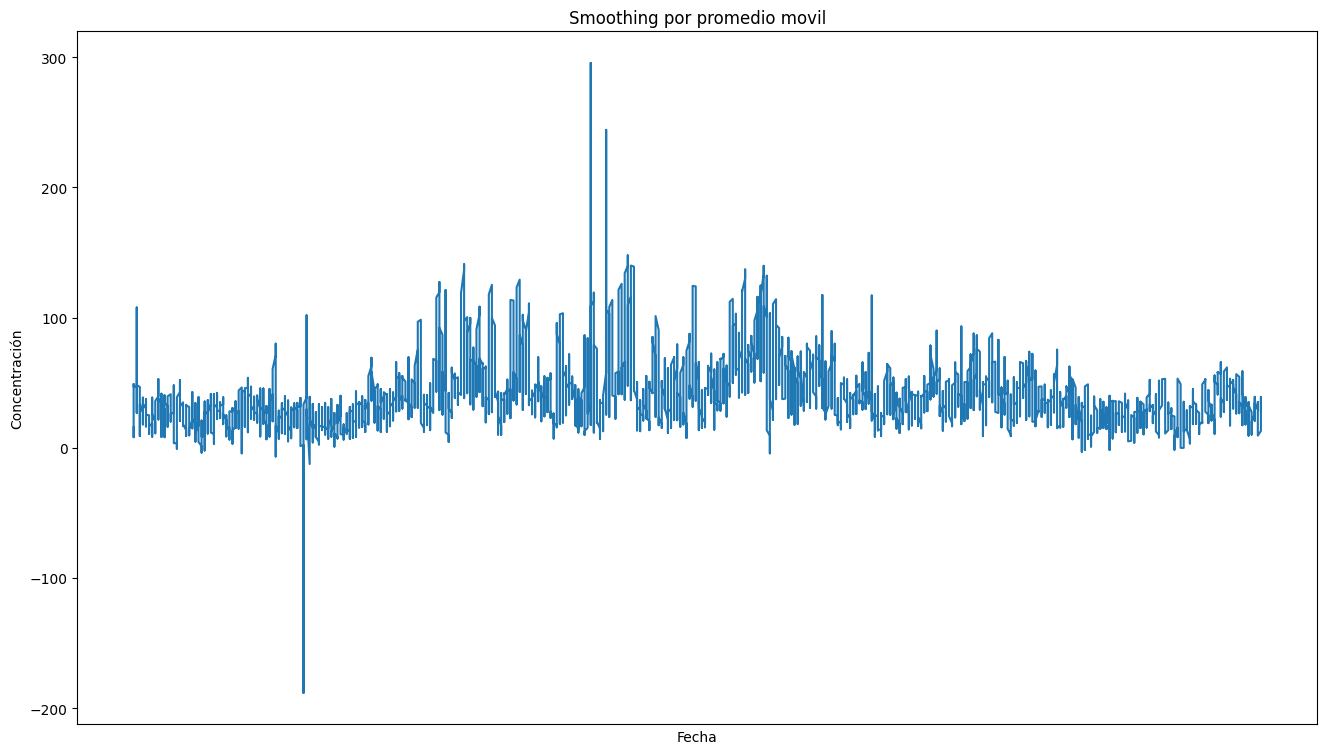

In [18]:
plt.figure(figsize=(16,9))
plt.plot(datos['Fecha'], datos['Moving_average'])
plt.ylabel('Concentración')
plt.xticks([])
plt.xlabel('Fecha')
plt.title('Smoothing por promedio movil')

## Smoothing moving average (weigthed)

In [19]:
weights = {'hora':list(range(0,24)),
                'peso':[1, 1, 1, 1, 1, 1, 2, 2, 5, 3, 1, 1,
                        1, 2, 4, 3, 2, 2, 5, 3, 2, 2, 1, 1]}

weights = pd.DataFrame(weights)

In [20]:
datos['hora_entero'] = datos['Hora'].str.split(':').str[0].astype(int)
datos = pd.merge( datos, weights, left_on='hora_entero', right_on='hora', how='left')
datos = datos.drop(columns=['hora_entero'])
datos.head()

,Parametro,Fecha,Hora,Concentraciones horarias,Unidad,Mean_by_day,Median_by_day,boundary_day,Moving_average,hora,peso
0,PM10,01/08/2025,23:00 - 0:00,27,µg/m_,25.333333,24.0,57,NaN,23,1
1,PM10,01/08/2025,0:00 - 1:00,34,µg/m_,25.333333,24.0,57,NaN,0,1
2,PM10,01/08/2025,1:00 - 2:00,5,µg/m_,25.333333,24.0,-7,15.8,1,1
3,PM10,01/08/2025,2:00 - 3:00,-7,µg/m_,25.333333,24.0,-7,14.2,2,1
4,PM10,01/08/2025,3:00 - 4:00,20,µg/m_,25.333333,24.0,-7,8.6,3,1


In [21]:
datos['hora_x_peso'] = datos['Concentraciones horarias'] * datos['peso']
productos = datos['hora_x_peso'].rolling(window=5, center=True).sum()
totales = datos['peso'].rolling(window=5, center=True).sum()
datos['Smoothing_weight'] = productos/totales
datos = datos.drop(columns=['hora_x_peso'])
datos.head()

,Parametro,Fecha,Hora,Concentraciones horarias,Unidad,Mean_by_day,Median_by_day,boundary_day,Moving_average,hora,peso,Smoothing_weight
0,PM10,01/08/2025,23:00 - 0:00,27,µg/m_,25.333333,24.0,57,NaN,23,1,NaN
1,PM10,01/08/2025,0:00 - 1:00,34,µg/m_,25.333333,24.0,57,NaN,0,1,NaN
2,PM10,01/08/2025,1:00 - 2:00,5,µg/m_,25.333333,24.0,-7,15.8,1,1,15.8
3,PM10,01/08/2025,2:00 - 3:00,-7,µg/m_,25.333333,24.0,-7,14.2,2,1,14.2
4,PM10,01/08/2025,3:00 - 4:00,20,µg/m_,25.333333,24.0,-7,8.6,3,1,8.6


Text(0.5, 1.0, 'Smoothing por promedio ponderado movil')

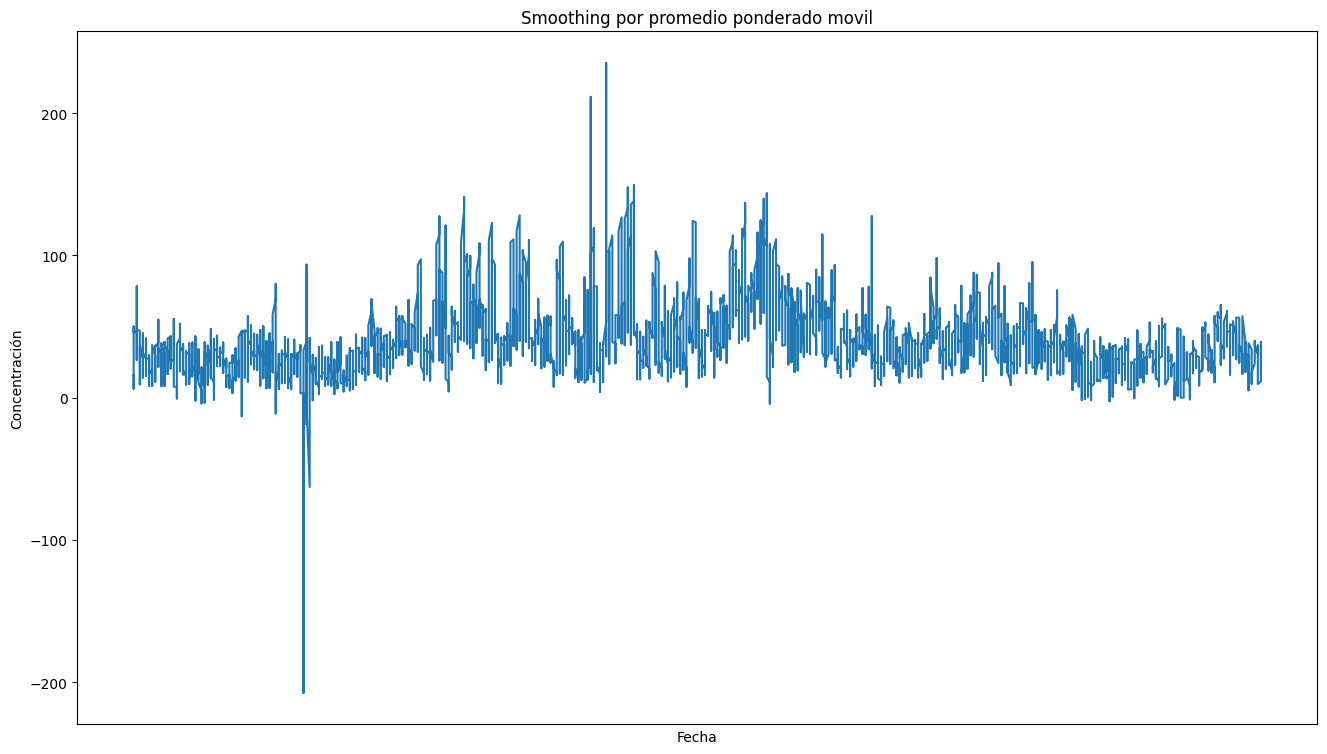

In [23]:
plt.figure(figsize=(16,9))
plt.plot(datos['Fecha'], datos['Smoothing_weight'])
plt.ylabel('Concentración')
plt.xticks([])
plt.xlabel('Fecha')
plt.title('Smoothing por promedio ponderado movil')

## Smoothing moving average per day

In [24]:
datos['MA_per_day'] = datos.groupby('Fecha')['Concentraciones horarias'].transform(lambda x: x.rolling(window=3, center=True).mean())
datos.head()

,Parametro,Fecha,Hora,Concentraciones horarias,Unidad,Mean_by_day,Median_by_day,boundary_day,Moving_average,hora,peso,Smoothing_weight,MA_per_day
0,PM10,01/08/2025,23:00 - 0:00,27,µg/m_,25.333333,24.0,57,NaN,23,1,NaN,NaN
1,PM10,01/08/2025,0:00 - 1:00,34,µg/m_,25.333333,24.0,57,NaN,0,1,NaN,22.000000
2,PM10,01/08/2025,1:00 - 2:00,5,µg/m_,25.333333,24.0,-7,15.8,1,1,15.8,10.666667
3,PM10,01/08/2025,2:00 - 3:00,-7,µg/m_,25.333333,24.0,-7,14.2,2,1,14.2,6.000000
4,PM10,01/08/2025,3:00 - 4:00,20,µg/m_,25.333333,24.0,-7,8.6,3,1,8.6,10.666667


Text(0.5, 1.0, 'Smoothing por promedio movil por dia')

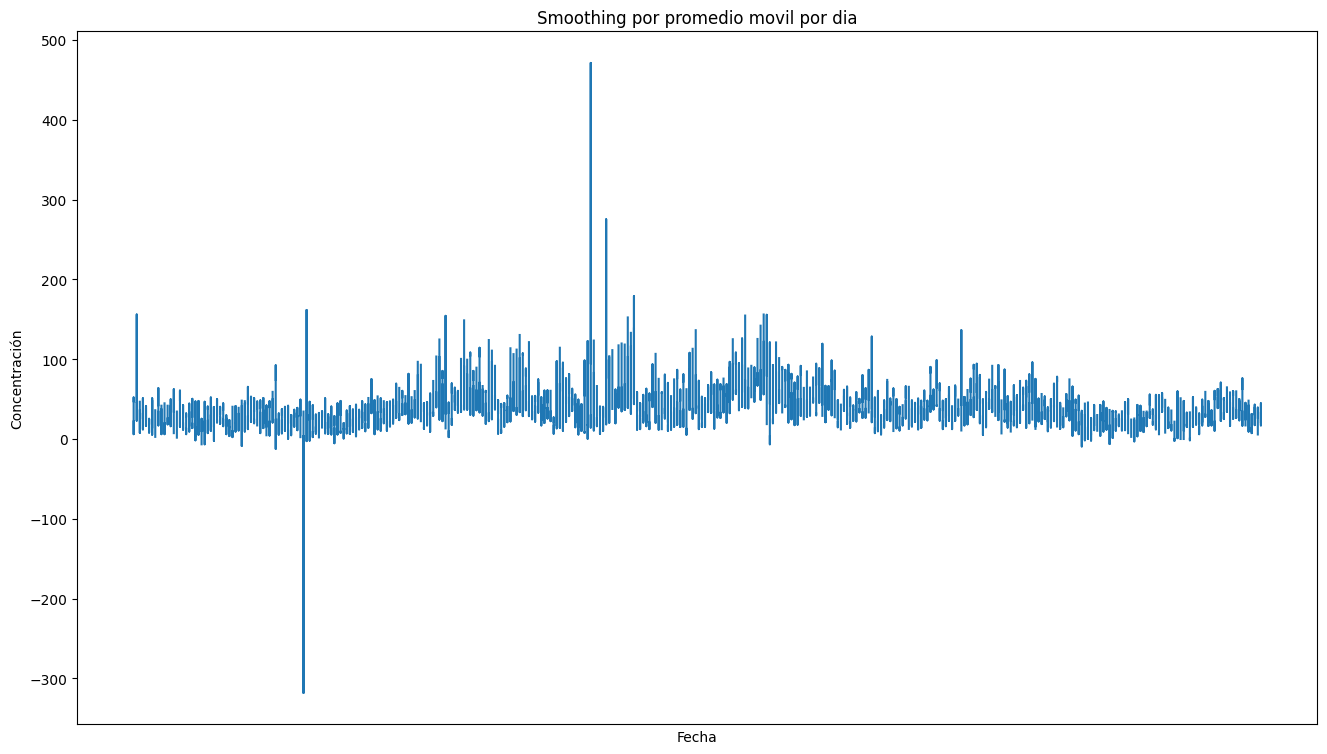

In [25]:
plt.figure(figsize=(16,9))
plt.plot(datos['Fecha'], datos['MA_per_day'])
plt.ylabel('Concentración')
plt.xticks([])
plt.xlabel('Fecha')
plt.title('Smoothing por promedio movil por dia')